# External Validation of PAM50 Molecular Subtype Classification on the NOU Breast Cancer Cohort

## Overview

This notebook evaluates the **CLAM-MB + UNI2-h** PAM50 molecular subtype classification pipeline, trained on **TCGA-BRCA** (986 slides, 10-fold CV), on an independent external cohort: the **NOU breast cancer dataset** (28 patients, multiple tissue crops per patient).

PAM50 labels are assigned at the **patient level** via majority vote across all tissue blocks per patient, consistent with the patient-level nature of molecular subtyping. Previous per-block annotations showed contradictory labels for 27/28 patients; this has been corrected.

We compare patching strategies (when results are available):
- **512px** (512×512 px patches at 40x native) -- effective ~17x
- **256px** (256×256 px patches at 40x native) -- effective ~35x
- **448px** (448×448 px patches at 40x native) -- effective ~20x, matching TCGA

### NOU Dataset (patient-level labels via majority vote)

| Subtype | Patients | TCGA class |
|---------|----------|------------|
| Luminal A | 21 | 0 |
| Luminal B | 3 | 1 |
| Basal-like (TN) | 1 | 2 |
| HER2-enriched | 3 | 3 |

### Important Caveats

1. **IHC surrogate labels**: NOU labels are based on IHC surrogate classification (ER, PR, HER2, Ki67), not PAM50 genomic assay. Triple-negative (TN) maps to Basal-like with ~80% concordance in the literature. Per-block IHC labels showed high intra-patient variability; patient-level majority vote was applied.
2. **Small cohort**: 28 patients limits statistical power. Bootstrap confidence intervals are reported.
3. **Severe class imbalance**: LumA dominates (21/28 patients). Minority classes have very few patients.
4. **Magnification**: NOU crops scanned on Aperio AT2 at native resolution (~40x). The 448px patch size best matches TCGA's 20x / 224px protocol.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc as calc_auc,
    balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706"]
CLASS_NAMES = ["LumA", "LumB", "Basal", "Her2"]
N_CLASSES = 4
CLASS_COLORS = dict(zip(CLASS_NAMES, PALETTE))

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

In [2]:
BASE_DIR = "../../.scratch/nou_validation"
METADATA_DIR = os.path.join(BASE_DIR, "metadata")
N_FOLDS = 10

ALL_CONFIGS = {
    "512px": {
        "results_dir": os.path.join(BASE_DIR, "results_corrected/predictions"),
        "figures_dir": os.path.join(BASE_DIR, "results_corrected/analysis/figures"),
    },
    "256px": {
        "results_dir": os.path.join(BASE_DIR, "results_256_corrected/predictions"),
        "figures_dir": os.path.join(BASE_DIR, "results_256_corrected/analysis/figures"),
    },
    "448px": {
        "results_dir": os.path.join(BASE_DIR, "results_448/predictions"),
        "figures_dir": os.path.join(BASE_DIR, "results_448/analysis/figures"),
    },
}

manifest = pd.read_csv(os.path.join(METADATA_DIR, "nou_slide_manifest.csv"))
pam50_csv = pd.read_csv(os.path.join(METADATA_DIR, "nou_pam50_dataset.csv"))
LABEL_MAP = {0: "LumA", 1: "LumB", 2: "Basal", 3: "Her2"}

CONFIGS = {}
datasets = {}
for tag, cfg in ALL_CONFIGS.items():
    ens_path = os.path.join(cfg["results_dir"], "ensemble_predictions.csv")
    if not os.path.isfile(ens_path):
        print(f"[{tag}] SKIPPED -- no ensemble_predictions.csv found")
        continue
    CONFIGS[tag] = cfg
    os.makedirs(cfg["figures_dir"], exist_ok=True)
    ens = pd.read_csv(ens_path)

    ens = ens.drop(columns=["true_label", "true_name"], errors="ignore")
    ens = ens.merge(
        pam50_csv[["slide_id", "case_id", "label"]].rename(columns={"label": "true_label"}),
        on=["slide_id", "case_id"], how="left",
    )
    ens["true_name"] = ens["true_label"].map(LABEL_MAP)

    merged = ens.merge(
        manifest[["slide_id", "EP", "EMT", "ANY", "grade", "hist_type",
                  "block_pam50_name", "block_pam50_label"]],
        on="slide_id", how="left",
    )
    datasets[tag] = merged
    print(f"[{tag}] slides={len(merged)}, patients={merged['case_id'].nunique()}")

first_tag = list(datasets.keys())[0]
print(f"\nTrue label distribution ({first_tag}, patient-level majority vote):")
print(datasets[first_tag]["true_name"].value_counts().to_string())
print(f"\nPatient-level distribution:")
print(datasets[first_tag].drop_duplicates("case_id")["true_name"].value_counts().to_string())

[512px] slides=202, patients=28
[256px] slides=203, patients=28
[448px] SKIPPED -- no ensemble_predictions.csv found

True label distribution (512px, patient-level majority vote):
true_name
LumA     151
LumB      23
Her2      22
Basal      6

Patient-level distribution:
true_name
LumA     21
LumB      3
Her2      3
Basal     1


## Image-Level Evaluation

In [3]:
def compute_image_metrics(df):
    labels = df["true_label"].values
    preds = df["pred_label"].values
    probs = df[["p_LumA", "p_LumB", "p_Basal", "p_Her2"]].values
    binary = label_binarize(labels, classes=list(range(N_CLASSES)))

    acc = (labels == preds).mean()
    bacc = balanced_accuracy_score(labels, preds)
    macro_auc = roc_auc_score(binary, probs, multi_class="ovr", average="macro")
    report = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
    wf1 = report["weighted avg"]["f1-score"]

    class_aucs = []
    for i in range(N_CLASSES):
        if binary[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(binary[:, i], probs[:, i])
            class_aucs.append(calc_auc(fpr, tpr))
        else:
            class_aucs.append(float("nan"))

    return {
        "labels": labels, "preds": preds, "probs": probs, "binary": binary,
        "acc": acc, "bacc": bacc, "macro_auc": macro_auc, "wf1": wf1,
        "class_aucs": class_aucs, "report": report,
    }

img_metrics = {tag: compute_image_metrics(datasets[tag]) for tag in CONFIGS}

for tag, m in img_metrics.items():
    print("=" * 64)
    print(f"  NOU External Validation | PAM50 | Image-Level | {tag}")
    print("=" * 64)
    print(f"  Macro AUC:           {m['macro_auc']:.4f}")
    print(f"  Overall Accuracy:    {m['acc']:.4f}")
    print(f"  Balanced Accuracy:   {m['bacc']:.4f}")
    print(f"  Weighted F1-Score:   {m['wf1']:.4f}")
    print()
    print(f"  {'Class':6s}  {'AUC':>6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'n':>5s}")
    print(f"  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*6}  {'-'*5}")
    for i, name in enumerate(CLASS_NAMES):
        r = m["report"][name]
        print(f"  {name:6s}  {m['class_aucs'][i]:6.4f}  {r['precision']:6.3f}  "
              f"{r['recall']:6.3f}  {r['f1-score']:6.3f}  {int(r['support']):5d}")
    print("=" * 64)
    print()

  NOU External Validation | PAM50 | Image-Level | 512px
  Macro AUC:           0.5534
  Overall Accuracy:    0.5248
  Balanced Accuracy:   0.2706
  Weighted F1-Score:   0.5677

  Class      AUC    Prec  Recall      F1      n
  ------  ------  ------  ------  ------  -----
  LumA    0.5754   0.800   0.636   0.708    151
  LumB    0.4967   0.108   0.174   0.133     23
  Basal   0.5119   0.000   0.000   0.000      6
  Her2    0.6295   0.171   0.273   0.211     22

  NOU External Validation | PAM50 | Image-Level | 256px
  Macro AUC:           0.5549
  Overall Accuracy:    0.3793
  Balanced Accuracy:   0.2593
  Weighted F1-Score:   0.4517

  Class      AUC    Prec  Recall      F1      n
  ------  ------  ------  ------  ------  -----
  LumA    0.5724   0.787   0.414   0.543    152
  LumB    0.5268   0.119   0.304   0.171     23
  Basal   0.4949   0.000   0.000   0.000      6
  Her2    0.6253   0.189   0.318   0.237     22



In [4]:
for tag, m in img_metrics.items():
    print(f"Classification Report -- Image-Level [{tag}]")
    print("=" * 60)
    print(classification_report(m["labels"], m["preds"], target_names=CLASS_NAMES))
    print()
print("=" * 60)

Classification Report -- Image-Level [512px]
              precision    recall  f1-score   support

        LumA       0.80      0.64      0.71       151
        LumB       0.11      0.17      0.13        23
       Basal       0.00      0.00      0.00         6
        Her2       0.17      0.27      0.21        22

    accuracy                           0.52       202
   macro avg       0.27      0.27      0.26       202
weighted avg       0.63      0.52      0.57       202


Classification Report -- Image-Level [256px]
              precision    recall  f1-score   support

        LumA       0.79      0.41      0.54       152
        LumB       0.12      0.30      0.17        23
       Basal       0.00      0.00      0.00         6
        Her2       0.19      0.32      0.24        22

    accuracy                           0.38       203
   macro avg       0.27      0.26      0.24       203
weighted avg       0.62      0.38      0.45       203




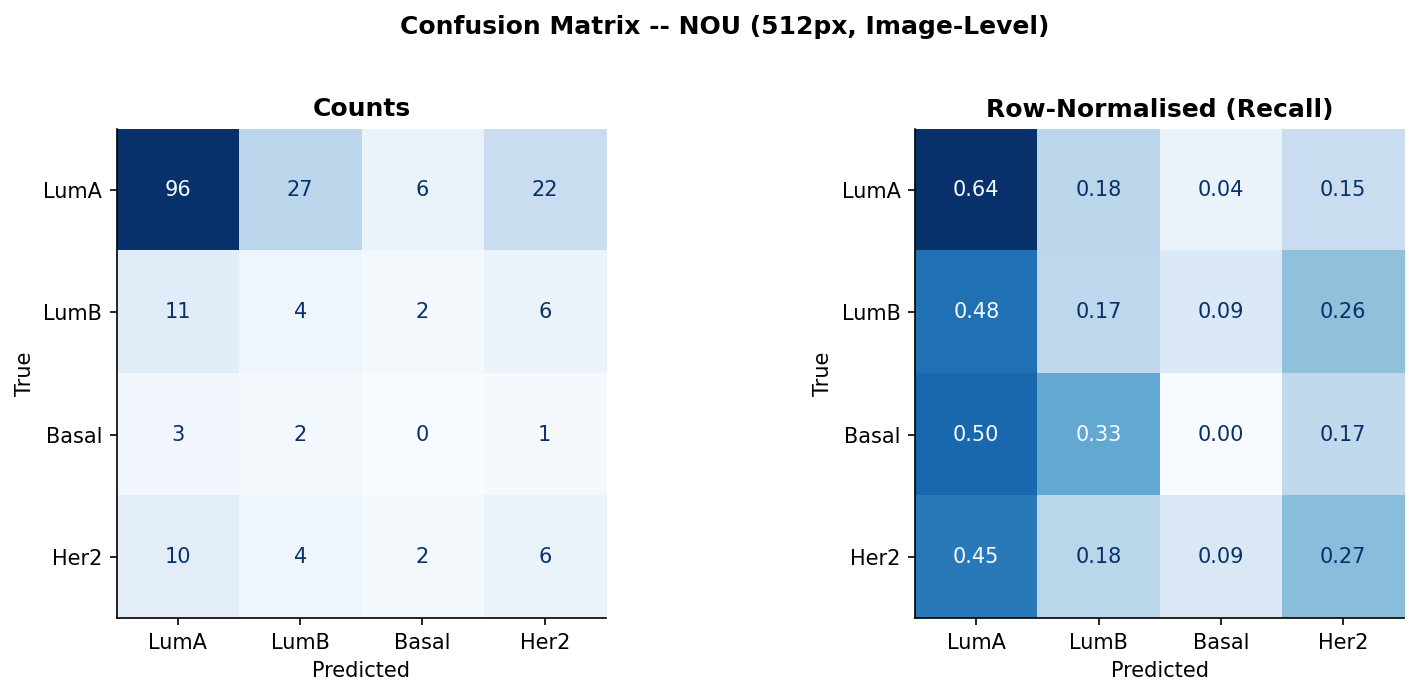

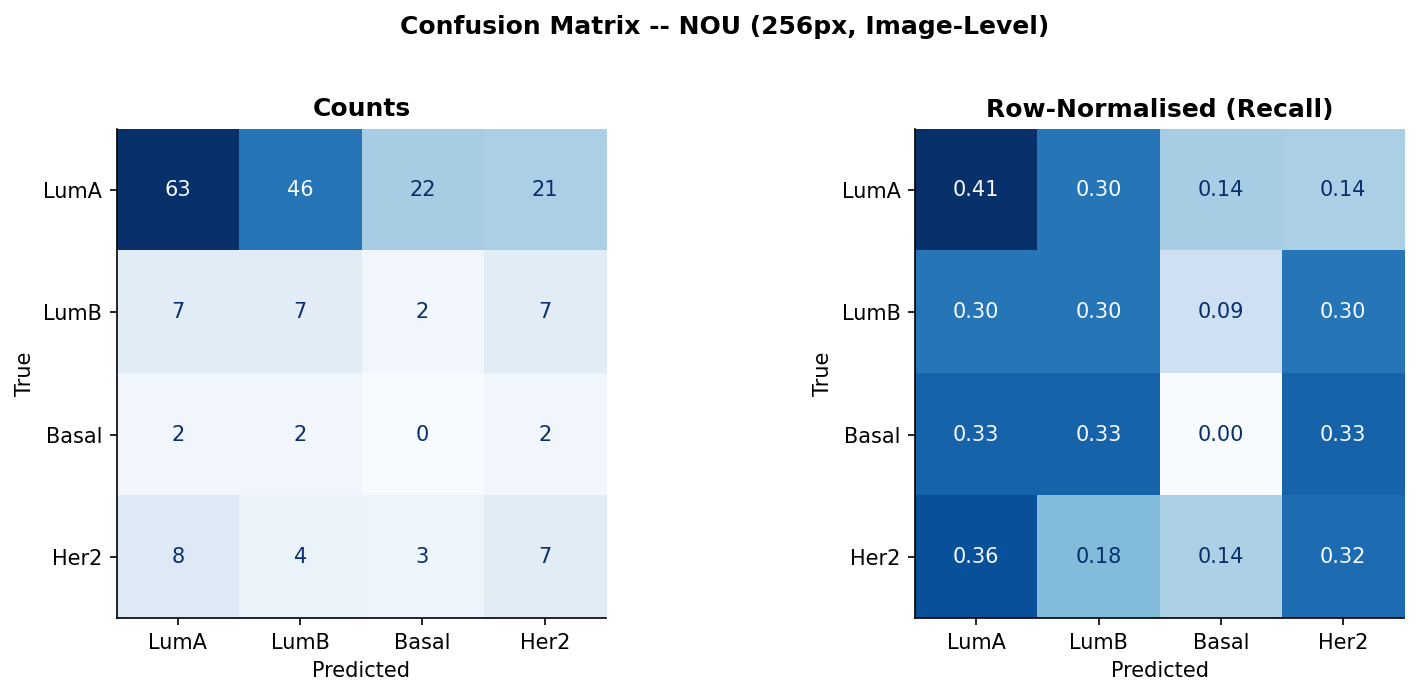

In [5]:
for tag, m in img_metrics.items():
    cm_raw = confusion_matrix(m["labels"], m["preds"])
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ConfusionMatrixDisplay(cm_raw, display_labels=CLASS_NAMES).plot(
        ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title("Counts")

    ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[1].set_title("Row-Normalised (Recall)")

    for a in axes:
        a.set_xlabel("Predicted")
        a.set_ylabel("True")

    fig.suptitle(f"Confusion Matrix -- NOU ({tag}, Image-Level)",
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.savefig(os.path.join(CONFIGS[tag]["figures_dir"], "confusion_matrix.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

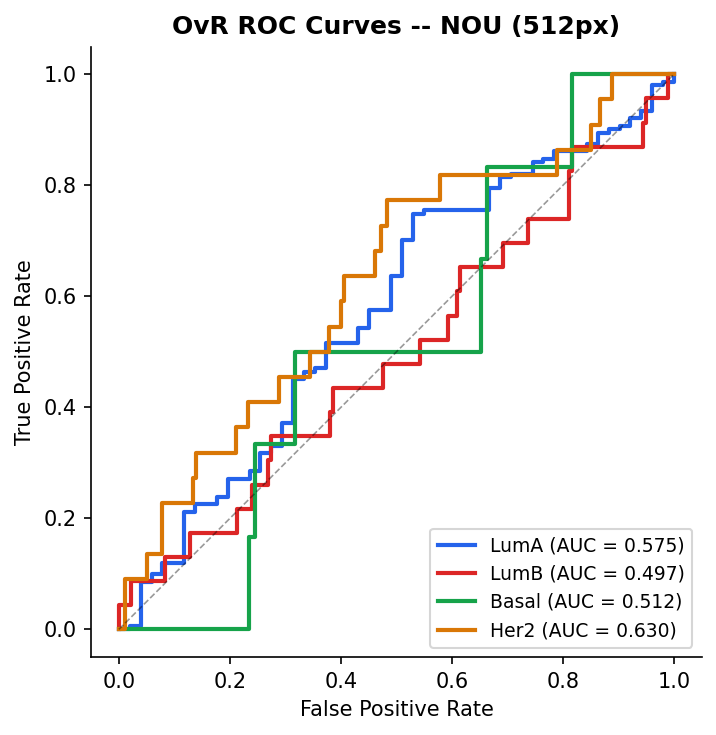

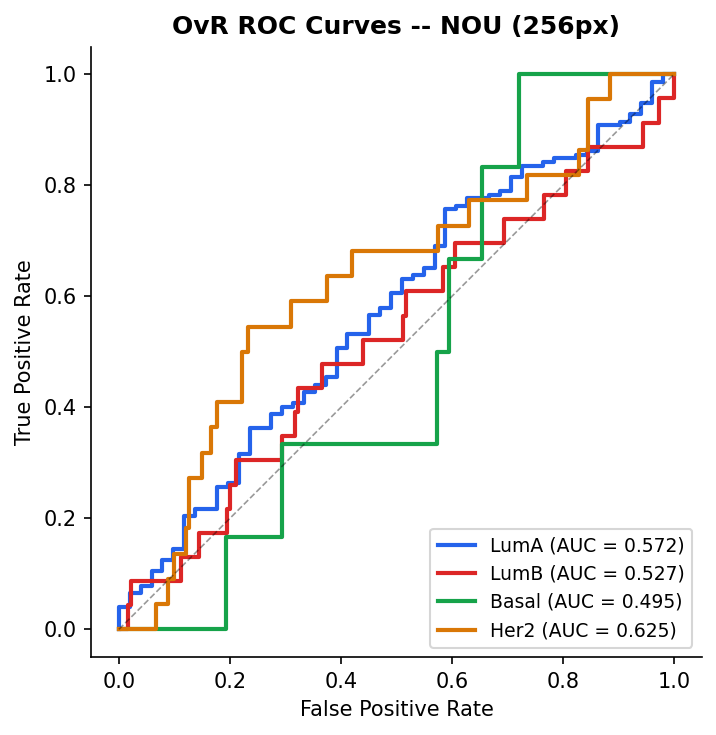

In [6]:
for tag, m in img_metrics.items():
    fig, ax = plt.subplots(figsize=(5.5, 5))
    for i, name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(m["binary"][:, i], m["probs"][:, i])
        auc_val = calc_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=CLASS_COLORS[name], lw=2,
                label=f"{name} (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"OvR ROC Curves -- NOU ({tag})")
    ax.legend(fontsize=9, loc="lower right")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.savefig(os.path.join(CONFIGS[tag]["figures_dir"], "roc_curves.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

## Patient-Level Evaluation (Primary Metric)

Each patient has multiple tissue crops. We aggregate by averaging the softmax probabilities across all crops per patient, then take the argmax as the patient-level prediction. This is the **primary evaluation** since PAM50 is a patient-level classification.

Bootstrap 95% confidence intervals (1000 resamples) are reported given the small cohort (n=28).

In [7]:
prob_cols = ["p_LumA", "p_LumB", "p_Basal", "p_Her2"]

def bootstrap_metric(labels, preds, probs, metric_fn, n_boot=2000, seed=42):
    """Bootstrap 95% CI for a metric function.

    Uses stratified resampling to ensure all classes appear in each
    bootstrap sample (critical for small cohorts with rare classes).
    """
    rng = np.random.RandomState(seed)
    n = len(labels)
    classes = np.unique(labels)
    class_idx = {c: np.where(labels == c)[0] for c in classes}
    scores = []
    for _ in range(n_boot):
        idx = []
        for c in classes:
            ci = class_idx[c]
            idx.append(rng.choice(ci, len(ci), replace=True))
        idx = np.concatenate(idx)
        rng.shuffle(idx)
        try:
            s = metric_fn(labels[idx], preds[idx], probs[idx])
        except (ValueError, ZeroDivisionError):
            continue
        if np.isfinite(s):
            scores.append(s)
    if len(scores) < 100:
        return float("nan"), float("nan")
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

def _acc(y, yp, _p):
    return (y == yp).mean()

def _bacc(y, yp, _p):
    return balanced_accuracy_score(y, yp)

def _macro_auc(y, _yp, p):
    yb = label_binarize(y, classes=list(range(N_CLASSES)))
    return roc_auc_score(yb, p, multi_class="ovr", average="macro")

patient_metrics = {}

for tag, df in datasets.items():
    pa = df.groupby("case_id").agg(
        true_label=("true_label", "first"),
        true_name=("true_name", "first"),
        n_crops=("slide_id", "count"),
        p_LumA=("p_LumA", "mean"),
        p_LumB=("p_LumB", "mean"),
        p_Basal=("p_Basal", "mean"),
        p_Her2=("p_Her2", "mean"),
    ).reset_index()

    pp = pa[prob_cols].values
    pa["pred_label"] = pp.argmax(axis=1)
    pa["pred_name"] = pa["pred_label"].map(dict(enumerate(CLASS_NAMES)))

    p_labels = pa["true_label"].values.astype(int)
    p_preds = pa["pred_label"].values.astype(int)
    p_binary = label_binarize(p_labels, classes=list(range(N_CLASSES)))

    p_acc = (p_labels == p_preds).mean()
    p_bacc = balanced_accuracy_score(p_labels, p_preds)
    try:
        p_macro_auc = roc_auc_score(p_binary, pp, multi_class="ovr", average="macro")
    except ValueError:
        p_macro_auc = float("nan")

    acc_ci = bootstrap_metric(p_labels, p_preds, pp, _acc)
    bacc_ci = bootstrap_metric(p_labels, p_preds, pp, _bacc)
    auc_ci = bootstrap_metric(p_labels, p_preds, pp, _macro_auc)

    patient_metrics[tag] = {
        "agg": pa, "acc": p_acc, "bacc": p_bacc, "macro_auc": p_macro_auc,
        "acc_ci": acc_ci, "bacc_ci": bacc_ci, "auc_ci": auc_ci,
    }

    print(f"Patient-Level Results [{tag}] (n={len(pa)} patients)")
    print(f"  Accuracy:          {p_acc:.4f}  95% CI [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]")
    print(f"  Balanced Accuracy: {p_bacc:.4f}  95% CI [{bacc_ci[0]:.4f}, {bacc_ci[1]:.4f}]")
    print(f"  Macro AUC:         {p_macro_auc:.4f}  95% CI [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")
    p_cm = confusion_matrix(p_labels, p_preds)
    print(pd.DataFrame(p_cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    print()

first_tag = list(patient_metrics.keys())[0]
print(f"Per-patient predictions ({first_tag}):")
print(patient_metrics[first_tag]["agg"][["case_id", "true_name", "pred_name", "n_crops",
                    "p_LumA", "p_LumB", "p_Basal", "p_Her2"]].to_string(index=False))

Patient-Level Results [512px] (n=28 patients)
  Accuracy:          0.6786  95% CI [0.5357, 0.8214]
  Balanced Accuracy: 0.3690  95% CI [0.2143, 0.4881]
  Macro AUC:         0.5291  95% CI [0.3459, 0.7112]
       LumA  LumB  Basal  Her2
LumA     17     4      0     0
LumB      2     0      0     1
Basal     1     0      0     0
Her2      1     0      0     2

Patient-Level Results [256px] (n=28 patients)
  Accuracy:          0.5357  95% CI [0.3571, 0.7143]
  Balanced Accuracy: 0.3214  95% CI [0.1429, 0.5357]
  Macro AUC:         0.5514  95% CI [0.3825, 0.7174]
       LumA  LumB  Basal  Her2
LumA     13     6      1     1
LumB      1     1      0     1
Basal     1     0      0     0
Her2      1     1      0     1

Per-patient predictions (512px):
 case_id true_name pred_name  n_crops   p_LumA   p_LumB  p_Basal   p_Her2
 1005137      LumA      LumB        8 0.371590 0.391941 0.100639 0.135830
 1005138      LumB      LumA        8 0.491948 0.376276 0.019591 0.112185
 1005140     Basal     

## Prediction Confidence Analysis

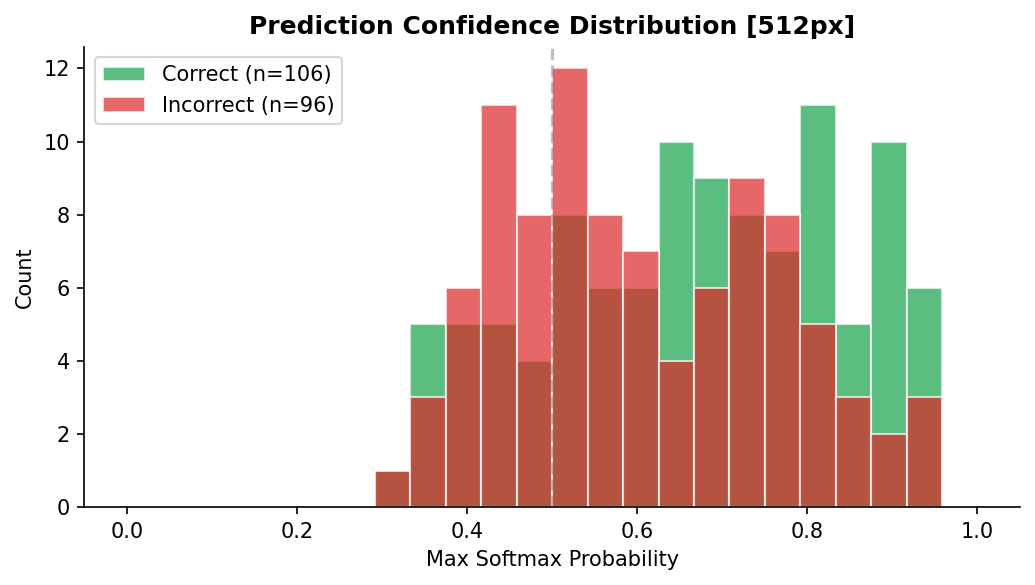

[512px] Mean confidence (correct):   0.6712
[512px] Mean confidence (incorrect): 0.6035



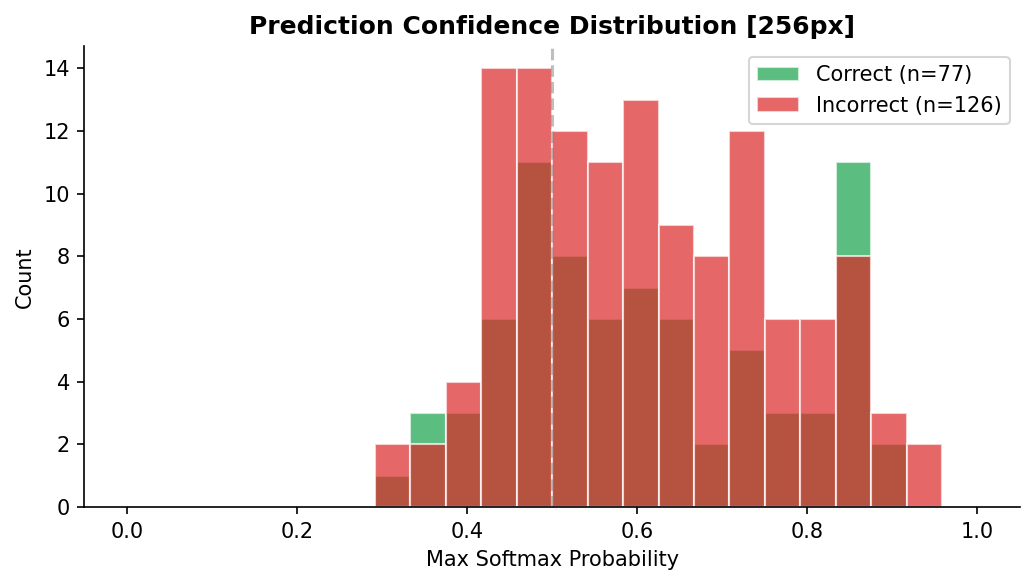

[256px] Mean confidence (correct):   0.6107
[256px] Mean confidence (incorrect): 0.6122



In [8]:
for tag, m in img_metrics.items():
    correct = m["labels"] == m["preds"]
    conf = m["probs"].max(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    bins = np.linspace(0, 1, 25)
    ax.hist(conf[correct], bins=bins, alpha=0.7, label=f"Correct (n={correct.sum()})",
            color="#16A34A", edgecolor="white")
    ax.hist(conf[~correct], bins=bins, alpha=0.7, label=f"Incorrect (n={(~correct).sum()})",
            color="#DC2626", edgecolor="white")
    ax.set_xlabel("Max Softmax Probability")
    ax.set_ylabel("Count")
    ax.set_title(f"Prediction Confidence Distribution [{tag}]")
    ax.legend()
    ax.axvline(0.5, color="gray", ls="--", alpha=0.5)
    fig.tight_layout()
    plt.savefig(os.path.join(CONFIGS[tag]["figures_dir"], "confidence.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[{tag}] Mean confidence (correct):   {conf[correct].mean():.4f}")
    print(f"[{tag}] Mean confidence (incorrect): {conf[~correct].mean():.4f}")
    print()

## Ensemble Agreement Analysis

For each slide, we check how many of the 10 fold models agree on the predicted class.

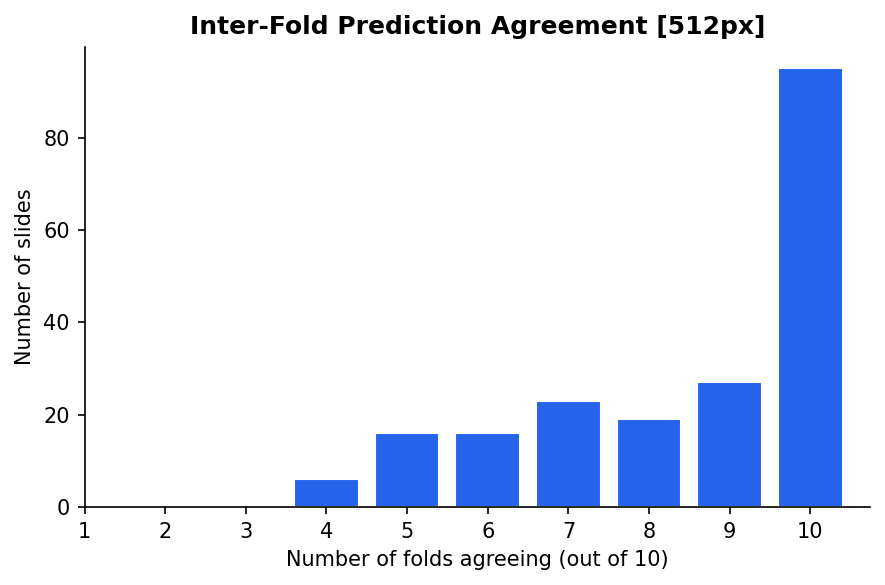

[512px] Mean agreement: 8.4/10 folds
[512px] Unanimous (10/10): 95 slides (47.0%)
[512px] Majority (>=6/10): 180 slides (89.1%)



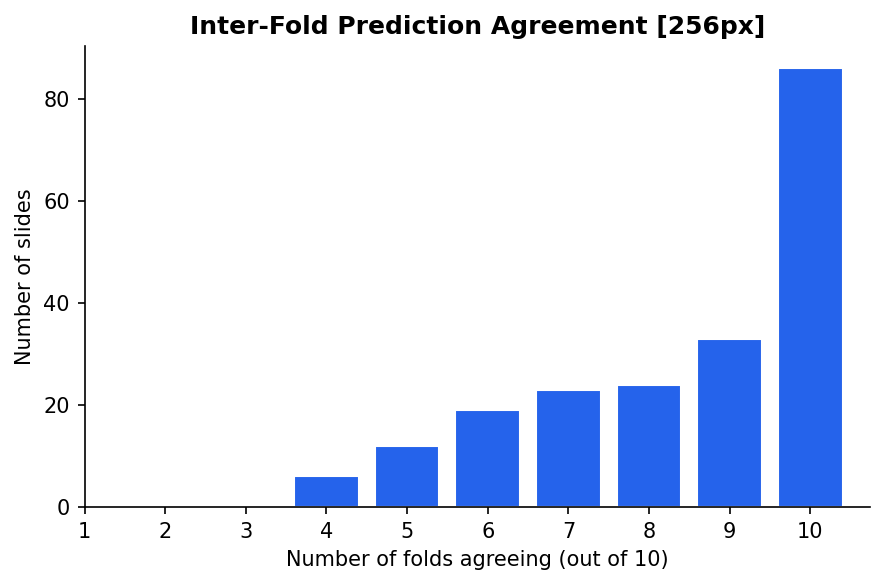

[256px] Mean agreement: 8.4/10 folds
[256px] Unanimous (10/10): 86 slides (42.4%)
[256px] Majority (>=6/10): 185 slides (91.1%)



In [9]:
from scipy.stats import mode as scipy_mode

for tag, cfg in CONFIGS.items():
    fold_preds_all = []
    for fold in range(N_FOLDS):
        fp = os.path.join(cfg["results_dir"], f"fold_{fold}_predictions.csv")
        if os.path.exists(fp):
            fold_df = pd.read_csv(fp)
            fold_preds_all.append(fold_df[["slide_id", "pred_label"]].rename(
                columns={"pred_label": f"fold_{fold}"}))

    if not fold_preds_all:
        continue

    agreement_df = fold_preds_all[0]
    for fp in fold_preds_all[1:]:
        agreement_df = agreement_df.merge(fp, on="slide_id")

    fold_cols = [c for c in agreement_df.columns if c.startswith("fold_")]
    preds_matrix = agreement_df[fold_cols].values

    modes = scipy_mode(preds_matrix, axis=1, keepdims=False)
    n_agree = np.array([(row == m).sum() for row, m in zip(preds_matrix, modes.mode)])

    fig, ax = plt.subplots(figsize=(6, 4))
    counts = pd.Series(n_agree).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#2563EB", edgecolor="white")
    ax.set_xlabel("Number of folds agreeing (out of 10)")
    ax.set_ylabel("Number of slides")
    ax.set_title(f"Inter-Fold Prediction Agreement [{tag}]")
    ax.set_xticks(range(1, 11))
    fig.tight_layout()
    plt.savefig(os.path.join(cfg["figures_dir"], "fold_agreement.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[{tag}] Mean agreement: {n_agree.mean():.1f}/10 folds")
    print(f"[{tag}] Unanimous (10/10): {(n_agree == 10).sum()} slides ({(n_agree == 10).mean()*100:.1f}%)")
    print(f"[{tag}] Majority (>=6/10): {(n_agree >= 6).sum()} slides ({(n_agree >= 6).mean()*100:.1f}%)")
    print()

## PAM50 vs CTC Status Correlation

We examine whether the predicted molecular subtypes correlate with circulating tumour cell (CTC) status. In the literature, Basal-like tumours are associated with higher CTC positivity and EMT marker expression.

[512px] Predicted PAM50 subtype vs CTC ANY status:
CTC_status  CTC+  CTC-  All
pred_name                  
Basal          2     8   10
Her2           8    27   35
LumA          37    83  120
LumB          14    23   37
All           61   141  202

[512px] True (IHC) subtype vs CTC ANY status:
CTC_status  CTC+  CTC-  All
true_name                  
Basal          1     5    6
Her2           6    16   22
LumA          48   103  151
LumB           6    17   23
All           61   141  202



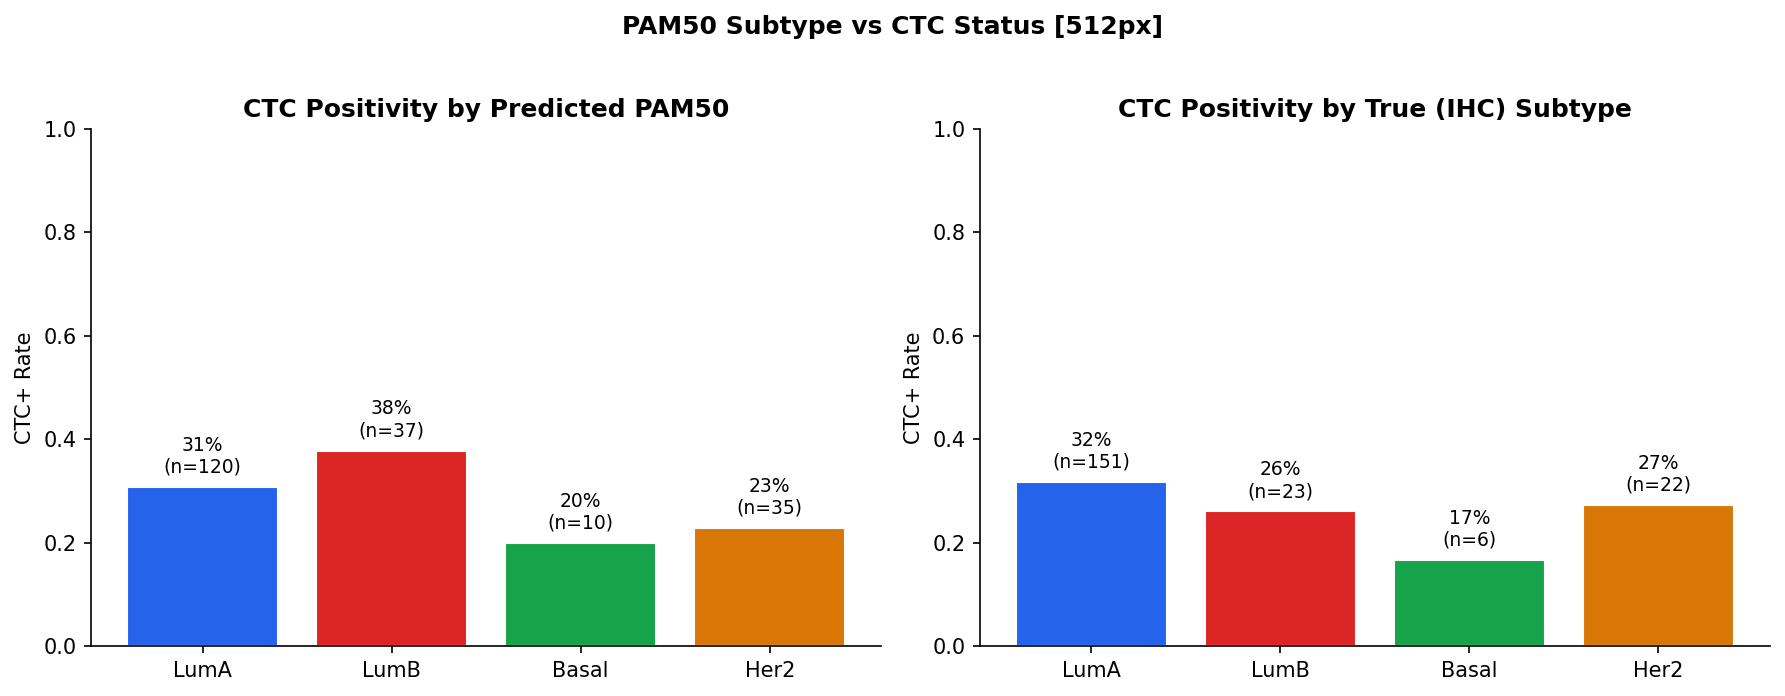

[256px] Predicted PAM50 subtype vs CTC ANY status:
CTC_status  CTC+  CTC-  All
pred_name                  
Basal          7    20   27
Her2          10    27   37
LumA          23    57   80
LumB          21    38   59
All           61   142  203

[256px] True (IHC) subtype vs CTC ANY status:
CTC_status  CTC+  CTC-  All
true_name                  
Basal          1     5    6
Her2           6    16   22
LumA          48   104  152
LumB           6    17   23
All           61   142  203



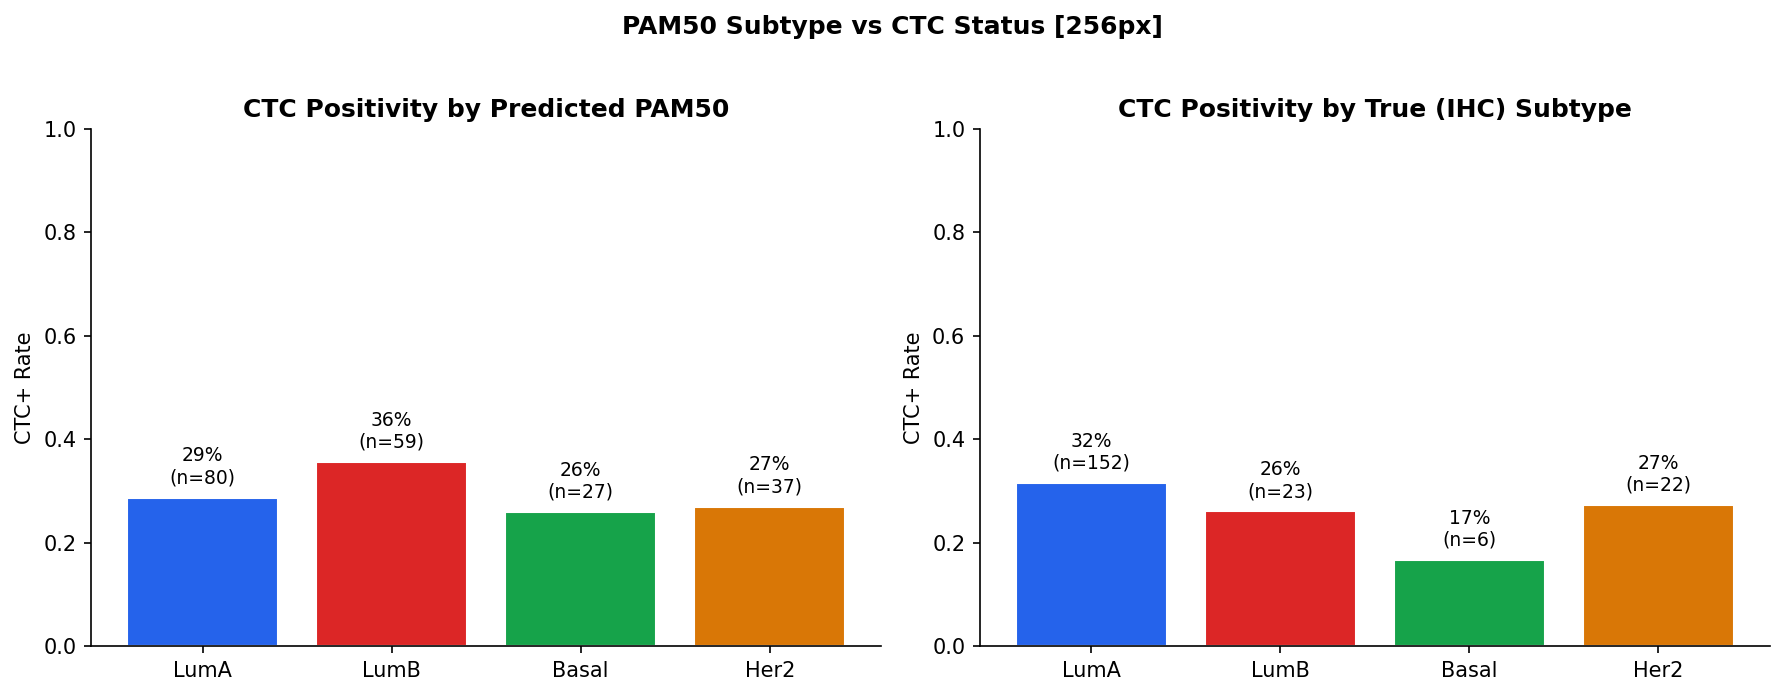

In [10]:
for tag, df in datasets.items():
    ctc_df = df.dropna(subset=["ANY"]).copy()
    ctc_df["CTC_status"] = ctc_df["ANY"].map({0: "CTC-", 1: "CTC+"})

    ct_pred = pd.crosstab(ctc_df["pred_name"], ctc_df["CTC_status"], margins=True)
    print(f"[{tag}] Predicted PAM50 subtype vs CTC ANY status:")
    print(ct_pred)
    print()

    ct_true = pd.crosstab(ctc_df["true_name"], ctc_df["CTC_status"], margins=True)
    print(f"[{tag}] True (IHC) subtype vs CTC ANY status:")
    print(ct_true)
    print()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, col, title in [(axes[0], "pred_name", "Predicted PAM50"),
                            (axes[1], "true_name", "True (IHC) Subtype")]:
        rates = ctc_df.groupby(col)["ANY"].mean().reindex(CLASS_NAMES).fillna(0)
        counts = ctc_df.groupby(col)["ANY"].count().reindex(CLASS_NAMES).fillna(0)
        bars = ax.bar(CLASS_NAMES, rates.values,
                      color=[CLASS_COLORS[n] for n in CLASS_NAMES], edgecolor="white")
        for bar, rate, n in zip(bars, rates.values, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{rate:.0%}\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
        ax.set_ylabel("CTC+ Rate")
        ax.set_title(f"CTC Positivity by {title}")
        ax.set_ylim([0, 1.0])

    fig.suptitle(f"PAM50 Subtype vs CTC Status [{tag}]", fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.savefig(os.path.join(CONFIGS[tag]["figures_dir"], "pam50_vs_ctc.png"),
                dpi=300, bbox_inches="tight")
    plt.show()

## Comparison with TCGA-BRCA Internal Validation

In [11]:
tcga_results = {
    "Macro AUC": 0.8879,
    "Accuracy": 0.7181,
    "Weighted F1": 0.7179,
    "LumA AUC": 0.8967,
    "LumB AUC": 0.8174,
    "Basal AUC": 0.9529,
    "Her2 AUC": 0.8846,
}

def build_nou_row(m):
    return {
        "Macro AUC": m["macro_auc"], "Accuracy": m["acc"],
        "Weighted F1": m["wf1"],
        "LumA AUC": m["class_aucs"][0], "LumB AUC": m["class_aucs"][1],
        "Basal AUC": m["class_aucs"][2], "Her2 AUC": m["class_aucs"][3],
    }

comp = {"Metric": list(tcga_results.keys()),
        "TCGA-BRCA (10-fold CV)": [f"{v:.4f}" for v in tcga_results.values()]}

for tag, m in img_metrics.items():
    nr = build_nou_row(m)
    comp[f"NOU {tag}"] = [f"{nr[k]:.4f}" for k in tcga_results]

comp_df = pd.DataFrame(comp)
print("Comparison: TCGA-BRCA Internal vs NOU External (512px / 256px)")
print("=" * 80)
print(comp_df.to_string(index=False))
print("=" * 80)
print()
print("Note: TCGA uses PAM50 genomic labels; NOU uses IHC surrogate labels.")
print("TN (IHC) mapped to Basal-like (PAM50) with ~80% concordance.")

Comparison: TCGA-BRCA Internal vs NOU External (512px / 256px)
     Metric TCGA-BRCA (10-fold CV) NOU 512px NOU 256px
  Macro AUC                 0.8879    0.5534    0.5549
   Accuracy                 0.7181    0.5248    0.3793
Weighted F1                 0.7179    0.5677    0.4517
   LumA AUC                 0.8967    0.5754    0.5724
   LumB AUC                 0.8174    0.4967    0.5268
  Basal AUC                 0.9529    0.5119    0.4949
   Her2 AUC                 0.8846    0.6295    0.6253

Note: TCGA uses PAM50 genomic labels; NOU uses IHC surrogate labels.
TN (IHC) mapped to Basal-like (PAM50) with ~80% concordance.


## Summary

In [12]:
tags = list(CONFIGS.keys())
print("=" * 70)
print("  CLAM-MB + UNI2-h | NOU External Validation | PAM50 Subtyping")
print("  Labels: patient-level majority vote of IHC surrogate annotations")
print("=" * 70)
print()
print(f"  Classes:  {', '.join(CLASS_NAMES)}")
print()

col_w = 10
header = f"  {'Metric':<24s}" + "".join(f"  {t:>{col_w}s}" for t in tags)
print(header)
print("  " + "-" * (len(header.strip())))

def _v(d, tag, key):
    return d.get(tag, {}).get(key, float("nan"))

summary_rows = []
summary_rows.append(("Slides", {t: f"{len(datasets[t])}" for t in tags}))
summary_rows.append(("Patients", {t: f"{datasets[t]['case_id'].nunique()}" for t in tags}))
summary_rows.append(("", {}))
summary_rows.append(("-- Image-Level --", {}))
summary_rows.append(("Macro AUC", {t: f"{_v(img_metrics,t,'macro_auc'):.4f}" for t in tags}))
summary_rows.append(("Accuracy", {t: f"{_v(img_metrics,t,'acc'):.4f}" for t in tags}))
summary_rows.append(("Balanced Accuracy", {t: f"{_v(img_metrics,t,'bacc'):.4f}" for t in tags}))
summary_rows.append(("Weighted F1", {t: f"{_v(img_metrics,t,'wf1'):.4f}" for t in tags}))
summary_rows.append(("", {}))
summary_rows.append(("-- Patient-Level --", {}))
for metric, key, ci_key in [("Macro AUC", "macro_auc", "auc_ci"),
                             ("Accuracy", "acc", "acc_ci"),
                             ("Balanced Accuracy", "bacc", "bacc_ci")]:
    vals = {}
    for t in tags:
        pm = patient_metrics.get(t, {})
        v = pm.get(key, float("nan"))
        ci = pm.get(ci_key, (float("nan"), float("nan")))
        vals[t] = f"{v:.4f} [{ci[0]:.2f},{ci[1]:.2f}]"
    summary_rows.append((metric, vals))
summary_rows.append(("", {}))
summary_rows.append(("-- Per-Class AUC --", {}))
for i, name in enumerate(CLASS_NAMES):
    vals = {}
    for t in tags:
        im = img_metrics.get(t, {})
        aucs = im.get("class_aucs", [float("nan")] * N_CLASSES)
        vals[t] = f"{aucs[i]:.4f}"
    summary_rows.append((name, vals))

for label, vals in summary_rows:
    line = f"  {label:<24s}"
    for t in tags:
        line += f"  {vals.get(t, ''):>{col_w + 14}s}" if vals else f"  {'':>{col_w}s}"
    print(line)

print("=" * 70)

csv_data = {"Metric": [r[0] for r, _ in zip(summary_rows, summary_rows) if r[0] and not r[0].startswith("--")]}
for t in tags:
    csv_data[t] = [r[1].get(t, "") for r in summary_rows if r[0] and not r[0].startswith("--")]
summary_df = pd.DataFrame(csv_data)
csv_path = os.path.join(BASE_DIR, "comparison_results.csv")
summary_df.to_csv(csv_path, index=False)
print(f"\nSaved comparison CSV: {csv_path}")

  CLAM-MB + UNI2-h | NOU External Validation | PAM50 Subtyping
  Labels: patient-level majority vote of IHC surrogate annotations

  Classes:  LumA, LumB, Basal, Her2

  Metric                         512px       256px
  ------------------------------------------------
  Slides                                         202                       203
  Patients                                        28                        28
                                                  
  -- Image-Level --                               
  Macro AUC                                   0.5534                    0.5549
  Accuracy                                    0.5248                    0.3793
  Balanced Accuracy                           0.2706                    0.2593
  Weighted F1                                 0.5677                    0.4517
                                                  
  -- Patient-Level --                             
  Macro AUC                       0.5291 [0.35,0.71]